# R6 - Selección de la combinación arquitectura CNN + representación de entrada

**Candidatas (6 combinaciones operativas)**

- Arquitecturas: ResNet50, DenseNet121 y ConvNeXt-Tiny.
- Condiciones: **A** (imagen completa) y **B** (ROI automática obtenida con el segmentador U-Net fijo).
- La condición **C** (ROI de referencia) queda excluida: requiere la máscara de referencia, no está disponible en un uso real.

**Regla de selección**

1. Criterio principal: mayor ROC-AUC media en `validation` (media de las 3 semillas).
2. Criterios complementarios, que se reportan pero no modifican la selección: Average Precision, desviación estándar entre semillas, sensibilidad y especificidad (umbral 0.5).
3. Accuracy no se utiliza como criterio, por el desbalance de clases.
4. En caso de empate exacto en la ROC-AUC media, se seleccionaría la combinación con mayor Average Precision media.

In [10]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def locate_project_root() -> Path:
    current_dir = Path.cwd().resolve()

    for candidate in [current_dir, *current_dir.parents]:
        if (
            (candidate / "src").exists()
            and (candidate / "data").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto."
    )


PROJECT_ROOT = locate_project_root()

## 1. Configuración y fuentes

Fuentes de resultados:

- R4: `results/classification/r4_benchmark/analysis/` (condición A).
- R5: `results/classification/r5_input_representation/analysis/` (condiciones A, B y C; A se tomó de R4 sin reentrenar).

In [11]:
CLASSIFICATION_DIR = PROJECT_ROOT / "results" / "classification"
R4_DIR = CLASSIFICATION_DIR / "r4_benchmark" / "analysis"
R5_DIR = CLASSIFICATION_DIR / "r5_input_representation" / "analysis"
OUTPUT_DIR = CLASSIFICATION_DIR / "r6_model_selection"
FIGURES_DIR = OUTPUT_DIR / "figures"

ARCHS = ["resnet50", "densenet121", "convnext_tiny"]
SELECTION_CONDITIONS = ["A", "B"]  # C excluida de la selección
SEEDS = [42, 43, 44]

PRIMARY_METRIC = "roc_auc"
TIE_BREAK_METRIC = "average_precision"
REPORTED_METRICS = ["roc_auc", "average_precision", "sensitivity", "specificity"]

ARCH_LABELS = {"resnet50": "ResNet50", "densenet121": "DenseNet121", "convnext_tiny": "ConvNeXt-Tiny"}
CONDITION_LABELS = {"A": "A (imagen completa)", "B": "B (ROI automática)"}
METRIC_LABELS = {
    "roc_auc": "ROC-AUC",
    "average_precision": "AP",
    "sensitivity": "Sensibilidad",
    "specificity": "Especificidad",
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

r4_summary = pd.read_csv(R4_DIR / "r4_architecture_summary.csv")
r4_per_seed = pd.read_csv(R4_DIR / "r4_metrics_per_seed.csv")
r5_summary = pd.read_csv(R5_DIR / "r5_condition_summary.csv")
r5_per_seed = pd.read_csv(R5_DIR / "r5_metrics_per_seed.csv")
r5_run_validation = pd.read_csv(R5_DIR / "r5_run_validation.csv")

## 2. Verificación de los resultados consolidados

Antes de seleccionar se comprueba que:

1. las 27 corridas de R5 superaron las validaciones de protocolo, predicciones y métricas;
2. la media y la desviación estándar del resumen de R5 se reproducen a partir de los valores por semilla;
3. los valores de la condición A en R5 coinciden con los de R4 (por semilla, incluidos los IC 95 %).

In [12]:
TOL = 1e-12

# 1. Validación de las 27 corridas en R5
assert len(r5_run_validation) == 27
for column in ["protocol_check", "predictions_check", "metrics_crosscheck"]:
    assert (r5_run_validation[column] == "ok").all(), column

# 2. Resumen de R5 reproducido desde los valores por semilla
recomputed = (
    r5_per_seed
    .melt(id_vars=["architecture", "condition", "seed"], value_vars=REPORTED_METRICS, var_name="metric", value_name="value")
    .groupby(["architecture", "condition", "metric"])["value"]
    .agg(mean_check="mean", std_check=lambda values: values.std(ddof=1), n_check="count")
    .reset_index()
)
check = r5_summary.merge(recomputed, on=["architecture", "condition", "metric"], how="inner", validate="one_to_one")
assert len(check) == len(ARCHS) * 3 * len(REPORTED_METRICS)
assert (check["n_check"] == 3).all()
assert (check["mean"] - check["mean_check"]).abs().max() < TOL
assert (check["std_between_seeds"] - check["std_check"]).abs().max() < TOL

# 3. Condición A: R5 coincide con R4
a_per_seed = r5_per_seed[r5_per_seed["condition"] == "A"].merge(
    r4_per_seed, on=["architecture", "seed"], suffixes=("_r5", "_r4"), validate="one_to_one"
)
assert len(a_per_seed) == len(ARCHS) * len(SEEDS)
for metric in REPORTED_METRICS:
    assert (a_per_seed[f"{metric}_r5"] - a_per_seed[f"{metric}_r4"]).abs().max() < TOL, metric

a_summary = r5_summary[r5_summary["condition"] == "A"].drop(columns="condition").merge(
    r4_summary, on=["architecture", "metric"], suffixes=("_r5", "_r4"), validate="one_to_one"
)
assert len(a_summary) == len(ARCHS) * len(REPORTED_METRICS)
for column in ["mean", "std_between_seeds", "ci95_lower", "ci95_upper"]:
    assert (a_summary[f"{column}_r5"] - a_summary[f"{column}_r4"]).abs().max() < TOL, column

print("Resultados consolidados verificados: R5 coherente con sus valores por semilla y condición A idéntica a R4")

Resultados consolidados verificados: R5 coherente con sus valores por semilla y condición A idéntica a R4


## 3. Tabla de las seis combinaciones operativas

Valores de `validation`: media ± desviación estándar entre las 3 semillas. La tabla se ordena por ROC-AUC media de mayor a menor únicamente para facilitar la lectura.

In [13]:
candidates_long = r5_summary[r5_summary["condition"].isin(SELECTION_CONDITIONS)]
assert set(candidates_long["condition"]) == set(SELECTION_CONDITIONS)

candidates = candidates_long.pivot(
    index=["architecture", "condition"],
    columns="metric",
    values=["mean", "std_between_seeds", "ci95_lower", "ci95_upper"],
)
candidates.columns = [f"{metric}_{statistic}" for statistic, metric in candidates.columns]
candidates = candidates.reset_index()
assert len(candidates) == len(ARCHS) * len(SELECTION_CONDITIONS) == 6

candidates = candidates.sort_values(
    [f"{PRIMARY_METRIC}_mean", f"{TIE_BREAK_METRIC}_mean"], ascending=False
).reset_index(drop=True)
candidates.insert(0, "order_by_roc_auc", np.arange(1, len(candidates) + 1))


def mean_sd(row, metric):
    return f"{row[f'{metric}_mean']:.3f} ± {row[f'{metric}_std_between_seeds']:.3f}"


compact_table = pd.DataFrame(
    {
        "Arquitectura": candidates["architecture"].map(ARCH_LABELS),
        "Condición": candidates["condition"].map(CONDITION_LABELS),
        "ROC-AUC media ± DE": candidates.apply(mean_sd, axis=1, metric="roc_auc"),
        "AP media ± DE": candidates.apply(mean_sd, axis=1, metric="average_precision"),
        "Sensibilidad media ± DE": candidates.apply(mean_sd, axis=1, metric="sensitivity"),
        "Especificidad media ± DE": candidates.apply(mean_sd, axis=1, metric="specificity"),
        "IC 95 % ROC-AUC": candidates.apply(
            lambda row: f"[{row['roc_auc_ci95_lower']:.3f}, {row['roc_auc_ci95_upper']:.3f}]", axis=1
        ),
    }
)

candidates.to_csv(OUTPUT_DIR / "r6_candidates.csv", index=False)
compact_table.to_csv(OUTPUT_DIR / "r6_candidates_compact.csv", index=False)

compact_table

,Arquitectura,Condición,ROC-AUC media ± DE,AP media ± DE,Sensibilidad media ± DE,Especificidad media ± DE,IC 95 % ROC-AUC
0,DenseNet121,A (imagen completa),0.867 ± 0.018,0.539 ± 0.069,0.667 ± 0.095,0.890 ± 0.049,"[0.794, 0.927]"
1,ConvNeXt-Tiny,A (imagen completa),0.843 ± 0.037,0.541 ± 0.044,0.455 ± 0.276,0.916 ± 0.122,"[0.763, 0.905]"
2,ResNet50,A (imagen completa),0.803 ± 0.044,0.448 ± 0.101,0.470 ± 0.172,0.890 ± 0.104,"[0.712, 0.878]"
3,ConvNeXt-Tiny,B (ROI automática),0.782 ± 0.027,0.446 ± 0.030,0.500 ± 0.164,0.863 ± 0.164,"[0.668, 0.874]"
4,DenseNet121,B (ROI automática),0.772 ± 0.051,0.356 ± 0.027,0.379 ± 0.069,0.912 ± 0.075,"[0.693, 0.850]"
5,ResNet50,B (ROI automática),0.723 ± 0.008,0.338 ± 0.057,0.333 ± 0.026,0.888 ± 0.046,"[0.613, 0.817]"


## 4. Aplicación del criterio principal

Se selecciona la combinación con mayor ROC-AUC media. Si existiera un empate exacto, se aplicaría la AP media como desempate, según la regla definida.

In [14]:
max_auc = candidates[f"{PRIMARY_METRIC}_mean"].max()
tied = candidates[candidates[f"{PRIMARY_METRIC}_mean"] == max_auc]

if len(tied) > 1:
    print(f"Empate exacto en ROC-AUC media entre {len(tied)} combinaciones; se aplica AP media como desempate.")
    selected = tied.sort_values(f"{TIE_BREAK_METRIC}_mean", ascending=False).iloc[0]
else:
    selected = tied.iloc[0]

runner_up = candidates[
    ~((candidates["architecture"] == selected["architecture"]) & (candidates["condition"] == selected["condition"]))
].iloc[0]

print(
    "Combinación que satisface el criterio principal: "
    f"{ARCH_LABELS[selected['architecture']]} + {CONDITION_LABELS[selected['condition']]} "
    f"(ROC-AUC media = {selected['roc_auc_mean']:.4f})"
)

Combinación que satisface el criterio principal: DenseNet121 + A (imagen completa) (ROC-AUC media = 0.8670)


## 5. Comparación de las dos combinaciones con mayor ROC-AUC media

Se comparan la combinación seleccionada y la segunda según el criterio principal, con los valores ya consolidados.

In [15]:
comparison_rows = []
for metric in REPORTED_METRICS:
    comparison_rows.append(
        {
            "Métrica": METRIC_LABELS[metric],
            "Seleccionada: media ± DE": mean_sd(selected, metric),
            "Seleccionada: IC 95 %": f"[{selected[f'{metric}_ci95_lower']:.3f}, {selected[f'{metric}_ci95_upper']:.3f}]",
            "Segunda: media ± DE": mean_sd(runner_up, metric),
            "Segunda: IC 95 %": f"[{runner_up[f'{metric}_ci95_lower']:.3f}, {runner_up[f'{metric}_ci95_upper']:.3f}]",
            "Diferencia de medias (seleccionada − segunda)": f"{selected[f'{metric}_mean'] - runner_up[f'{metric}_mean']:+.3f}",
        }
    )

top_two_comparison = pd.DataFrame(comparison_rows)

print(
    f"Seleccionada: {ARCH_LABELS[selected['architecture']]} + {CONDITION_LABELS[selected['condition']]}\n"
    f"Segunda:      {ARCH_LABELS[runner_up['architecture']]} + {CONDITION_LABELS[runner_up['condition']]}"
)

auc_overlap = not (
    selected["roc_auc_ci95_lower"] > runner_up["roc_auc_ci95_upper"]
    or runner_up["roc_auc_ci95_lower"] > selected["roc_auc_ci95_upper"]
)
print("Los IC 95 % de ROC-AUC se superponen:", "sí" if auc_overlap else "no", "(descriptivo, no es una prueba)")

top_two_comparison

Seleccionada: DenseNet121 + A (imagen completa)
Segunda:      ConvNeXt-Tiny + A (imagen completa)
Los IC 95 % de ROC-AUC se superponen: sí (descriptivo, no es una prueba)


,Métrica,Seleccionada: media ± DE,Seleccionada: IC 95 %,Segunda: media ± DE,Segunda: IC 95 %,Diferencia de medias (seleccionada − segunda)
0,ROC-AUC,0.867 ± 0.018,"[0.794, 0.927]",0.843 ± 0.037,"[0.763, 0.905]",+0.024
1,AP,0.539 ± 0.069,"[0.405, 0.700]",0.541 ± 0.044,"[0.381, 0.700]",-0.002
2,Sensibilidad,0.667 ± 0.095,"[0.515, 0.803]",0.455 ± 0.276,"[0.303, 0.591]",+0.212
3,Especificidad,0.890 ± 0.049,"[0.852, 0.923]",0.916 ± 0.122,"[0.891, 0.938]",-0.026


## 6. Figura comparativa

ROC-AUC media (3 semillas) e IC 95 % bootstrap de las seis combinaciones operativas, con las arquitecturas en orden fijo y las condiciones A y B una junto a otra. La combinación seleccionada se identifica con marcador relleno.

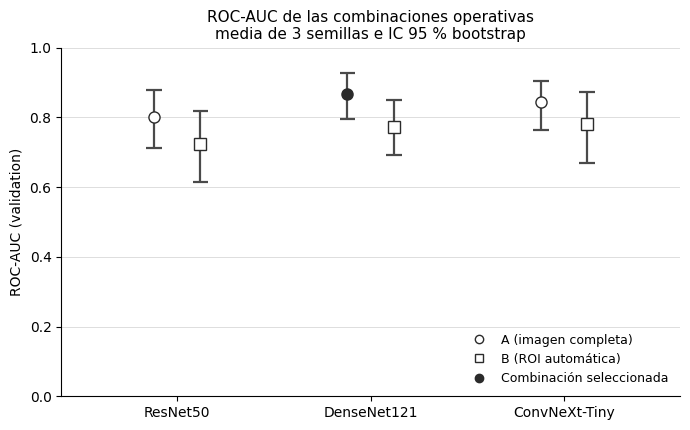

In [16]:
CONDITION_OFFSETS = {"A": -0.12, "B": 0.12}
CONDITION_MARKERS = {"A": "o", "B": "s"}

rows = candidates.set_index(["architecture", "condition"])
positions = np.arange(len(ARCHS))

fig, ax = plt.subplots(figsize=(7.0, 4.4))

for condition in SELECTION_CONDITIONS:
    for position, arch in zip(positions, ARCHS):
        row = rows.loc[(arch, condition)]
        x = position + CONDITION_OFFSETS[condition]
        is_selected = (arch == selected["architecture"]) and (condition == selected["condition"])

        ax.vlines(x, row["roc_auc_ci95_lower"], row["roc_auc_ci95_upper"], color="#4a4a4a", linewidth=1.6, zorder=2)
        ax.hlines([row["roc_auc_ci95_lower"], row["roc_auc_ci95_upper"]], x - 0.04, x + 0.04,
                  color="#4a4a4a", linewidth=1.6, zorder=2)
        ax.plot(
            x, row["roc_auc_mean"], linestyle="none", marker=CONDITION_MARKERS[condition], markersize=8,
            markerfacecolor="#2b2b2b" if is_selected else "white", markeredgecolor="#2b2b2b", zorder=3,
        )

    ax.plot([], [], linestyle="none", marker=CONDITION_MARKERS[condition], markerfacecolor="white",
            markeredgecolor="#2b2b2b", label=CONDITION_LABELS[condition])

ax.plot([], [], linestyle="none", marker="o", markerfacecolor="#2b2b2b", markeredgecolor="#2b2b2b",
        label="Combinación seleccionada")

ax.set_xticks(positions)
ax.set_xticklabels([ARCH_LABELS[arch] for arch in ARCHS])
ax.set_xlim(-0.6, len(ARCHS) - 0.4)
ax.set_ylim(0, 1)
ax.set_ylabel("ROC-AUC (validation)")
ax.set_title("ROC-AUC de las combinaciones operativas\nmedia de 3 semillas e IC 95 % bootstrap", fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.grid(axis="y", color="#dddddd", linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "r6_roc_auc_candidates_ci95.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.1 Combinación seleccionada frente a la segunda

Valores consolidados de las tres semillas (punto = media; barra = IC 95 % bootstrap de R4/R5) para las dos combinaciones con mayor ROC-AUC media. **ROC-AUC es el criterio principal de selección**; AP, sensibilidad y especificidad se muestran como criterios complementarios y no modifican la selección.

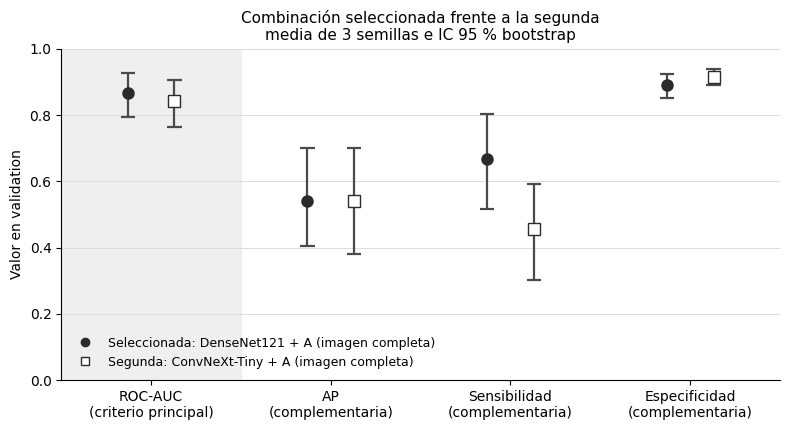

In [17]:
COMPARISON_STYLES = {
    "selected": {"offset": -0.13, "marker": "o", "face": "#2b2b2b"},
    "runner_up": {"offset": 0.13, "marker": "s", "face": "white"},
}
METRIC_ROLE = {
    "roc_auc": "criterio principal",
    "average_precision": "complementaria",
    "sensitivity": "complementaria",
    "specificity": "complementaria",
}


def combination_label(row):
    return f"{ARCH_LABELS[row['architecture']]} + {CONDITION_LABELS[row['condition']]}"


fig, ax = plt.subplots(figsize=(8.0, 4.4))
positions = np.arange(len(REPORTED_METRICS))

# Fondo que distingue el criterio principal
ax.axvspan(-0.5, 0.5, color="#efefef", zorder=0)

for key, row in (("selected", selected), ("runner_up", runner_up)):
    style = COMPARISON_STYLES[key]
    for position, metric in zip(positions, REPORTED_METRICS):
        x = position + style["offset"]
        lower, upper = row[f"{metric}_ci95_lower"], row[f"{metric}_ci95_upper"]
        ax.vlines(x, lower, upper, color="#4a4a4a", linewidth=1.6, zorder=2)
        ax.hlines([lower, upper], x - 0.04, x + 0.04, color="#4a4a4a", linewidth=1.6, zorder=2)
        ax.plot(x, row[f"{metric}_mean"], linestyle="none", marker=style["marker"], markersize=8,
                markerfacecolor=style["face"], markeredgecolor="#2b2b2b", zorder=3)
    prefix = "Seleccionada" if key == "selected" else "Segunda"
    ax.plot([], [], linestyle="none", marker=style["marker"], markerfacecolor=style["face"],
            markeredgecolor="#2b2b2b", label=f"{prefix}: {combination_label(row)}")

ax.set_xticks(positions)
ax.set_xticklabels([f"{METRIC_LABELS[metric]}\n({METRIC_ROLE[metric]})" for metric in REPORTED_METRICS])
ax.set_xlim(-0.5, len(REPORTED_METRICS) - 0.5)
ax.set_ylim(0, 1)
ax.set_ylabel("Valor en validation")
ax.set_title("Combinación seleccionada frente a la segunda\nmedia de 3 semillas e IC 95 % bootstrap", fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="lower left")
ax.grid(axis="y", color="#dddddd", linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "r6_selected_vs_runnerup_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.2 Matrices de confusión de la combinación seleccionada

Matrices de confusión en `validation` de cada una de las tres semillas de la combinación seleccionada, calculadas desde las predicciones guardadas del checkpoint de cada corrida con el umbral fijo 0.5. No se elige una semilla representativa ni se combinan probabilidades entre semillas: la figura muestra la variabilidad del comportamiento al umbral entre las tres ejecuciones. Los recuentos se contrastan con los de `r5_metrics_per_seed.csv`.

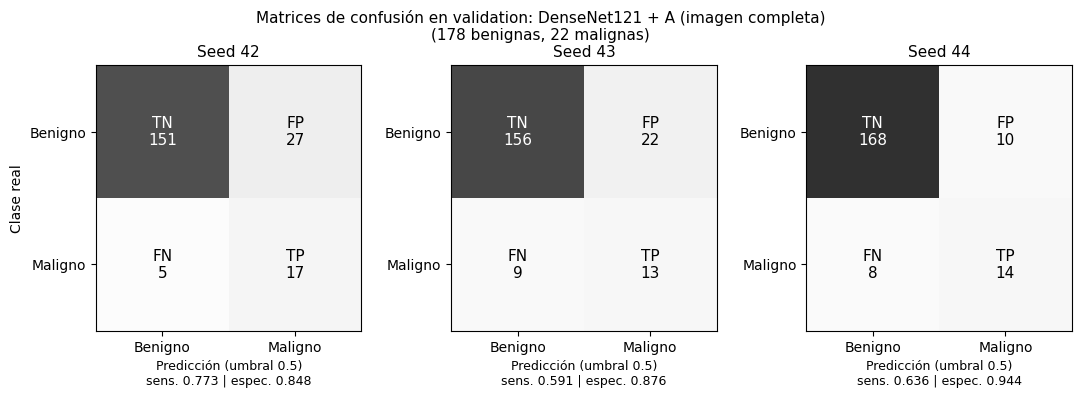

In [18]:
RUN_SOURCES = {"A": "r4_benchmark", "B": "r5_input_representation"}
CLASS_LABELS = ["Benigno", "Maligno"]
THRESHOLD = 0.5

selected_arch, selected_condition = selected["architecture"], selected["condition"]
confusion = {}

for seed in SEEDS:
    run_path = (
        CLASSIFICATION_DIR / RUN_SOURCES[selected_condition] / selected_arch / selected_condition
        / f"seed_{seed}" / "val_predictions_best_auc.csv"
    )
    predictions = pd.read_csv(run_path)
    assert len(predictions) == 200 and predictions["image_id"].is_unique, run_path

    y_true = predictions["y_true"].to_numpy()
    y_pred = (predictions["probability_malignant"].to_numpy() >= THRESHOLD).astype(int)

    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tp = int(((y_true == 1) & (y_pred == 1)).sum())

    # Contraste con los resultados consolidados de R4/R5
    consolidated = r5_per_seed[
        (r5_per_seed["architecture"] == selected_arch)
        & (r5_per_seed["condition"] == selected_condition)
        & (r5_per_seed["seed"] == seed)
    ]
    assert len(consolidated) == 1
    assert (tn, fp, fn, tp) == tuple(int(consolidated[k].iloc[0]) for k in ["tn", "fp", "fn", "tp"]), seed

    confusion[seed] = np.array([[tn, fp], [fn, tp]])

fig, axes = plt.subplots(1, len(SEEDS), figsize=(11.0, 3.8))

for ax, seed in zip(axes, SEEDS):
    matrix = confusion[seed]
    ax.imshow(matrix, cmap="Greys", vmin=0, vmax=200)

    cell_names = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            value = matrix[i, j]
            ax.text(j, i, f"{cell_names[i][j]}\n{value}", ha="center", va="center", fontsize=11,
                    color="white" if value > 100 else "black")

    sensitivity = matrix[1, 1] / matrix[1].sum()
    specificity = matrix[0, 0] / matrix[0].sum()

    ax.set_xticks([0, 1])
    ax.set_xticklabels(CLASS_LABELS)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(CLASS_LABELS)
    ax.set_xlabel(f"Predicción (umbral {THRESHOLD})\nsens. {sensitivity:.3f} | espec. {specificity:.3f}", fontsize=9)
    ax.set_title(f"Seed {seed}", fontsize=11)

axes[0].set_ylabel("Clase real")
fig.suptitle(
    f"Matrices de confusión en validation: {combination_label(selected)}\n(178 benignas, 22 malignas)",
    fontsize=11,
)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "r6_selected_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Registro formal de la selección

Se guarda un registro con la combinación seleccionada, la regla aplicada, sus valores y las fuentes utilizadas.

In [19]:
def metric_record(row):
    return {
        metric: {
            "mean": float(row[f"{metric}_mean"]),
            "std_between_seeds": float(row[f"{metric}_std_between_seeds"]),
            "ci95_lower": float(row[f"{metric}_ci95_lower"]),
            "ci95_upper": float(row[f"{metric}_ci95_upper"]),
        }
        for metric in REPORTED_METRICS
    }


selection_record = {
    "selected": {
        "architecture": selected["architecture"],
        "condition": selected["condition"],
        "metrics_validation": metric_record(selected),
    },
    "runner_up": {
        "architecture": runner_up["architecture"],
        "condition": runner_up["condition"],
        "metrics_validation": metric_record(runner_up),
    },
    "selection_rule": {
        "primary_criterion": "max mean ROC-AUC on validation (mean of 3 seeds)",
        "tie_break": "max mean Average Precision",
        "complementary_criteria": ["average_precision", "std_between_seeds", "sensitivity", "specificity"],
        "excluded_criteria": ["accuracy (class imbalance)"],
        "candidate_conditions": SELECTION_CONDITIONS,
        "excluded_conditions": {"C": "requires reference mask; idealized condition in R5"},
        "candidate_architectures": ARCHS,
        "seeds": SEEDS,
        "threshold": 0.5,
        "tied_on_primary": bool(len(tied) > 1),
    },
    "data": {
        "evaluation_split": "validation",
        "n_validation": 200,
        "test_used": False,
        "new_training": False,
    },
    "sources": [
        str((R4_DIR / "r4_architecture_summary.csv").relative_to(PROJECT_ROOT)),
        str((R4_DIR / "r4_metrics_per_seed.csv").relative_to(PROJECT_ROOT)),
        str((R5_DIR / "r5_condition_summary.csv").relative_to(PROJECT_ROOT)),
        str((R5_DIR / "r5_metrics_per_seed.csv").relative_to(PROJECT_ROOT)),
        str((R5_DIR / "r5_run_validation.csv").relative_to(PROJECT_ROOT)),
    ],
}

with open(OUTPUT_DIR / "r6_selection.json", "w") as f:
    json.dump(selection_record, f, indent=2, ensure_ascii=False)

print(json.dumps(selection_record["selected"], indent=2, ensure_ascii=False))

{
  "architecture": "densenet121",
  "condition": "A",
  "metrics_validation": {
    "roc_auc": {
      "mean": 0.8670411985018727,
      "std_between_seeds": 0.0178211883358673,
      "ci95_lower": 0.794420326864147,
      "ci95_upper": 0.92705354102826
    },
    "average_precision": {
      "mean": 0.5392436794605252,
      "std_between_seeds": 0.0688461034394784,
      "ci95_lower": 0.40480406508061,
      "ci95_upper": 0.6999291708439866
    },
    "sensitivity": {
      "mean": 0.6666666666666666,
      "std_between_seeds": 0.0946211817939151,
      "ci95_lower": 0.5151515151515151,
      "ci95_upper": 0.8030303030303031
    },
    "specificity": {
      "mean": 0.8895131086142323,
      "std_between_seeds": 0.04908367948345,
      "ci95_lower": 0.8520599250936329,
      "ci95_upper": 0.9232209737827716
    }
  }
}


In [20]:
s, r = selected, runner_up
print("Razón de la selección")
print("-" * 70)
print(
    f"Se selecciona {ARCH_LABELS[s['architecture']]} con {CONDITION_LABELS[s['condition']]} porque presenta la mayor "
    f"ROC-AUC media en validation entre las seis combinaciones operativas "
    f"({s['roc_auc_mean']:.3f} ± {s['roc_auc_std_between_seeds']:.3f}; IC 95 % "
    f"[{s['roc_auc_ci95_lower']:.3f}, {s['roc_auc_ci95_upper']:.3f}])."
)
print(
    f"La segunda combinación es {ARCH_LABELS[r['architecture']]} con {CONDITION_LABELS[r['condition']]} "
    f"(ROC-AUC {r['roc_auc_mean']:.3f} ± {r['roc_auc_std_between_seeds']:.3f}; diferencia de medias "
    f"{s['roc_auc_mean'] - r['roc_auc_mean']:+.3f})."
)
print(
    f"Criterios complementarios de la seleccionada: AP {mean_sd(s, 'average_precision')}, "
    f"sensibilidad {mean_sd(s, 'sensitivity')}, especificidad {mean_sd(s, 'specificity')}."
)
print("La selección se realizó solo con validation; test no se ha utilizado.")

Razón de la selección
----------------------------------------------------------------------
Se selecciona DenseNet121 con A (imagen completa) porque presenta la mayor ROC-AUC media en validation entre las seis combinaciones operativas (0.867 ± 0.018; IC 95 % [0.794, 0.927]).
La segunda combinación es ConvNeXt-Tiny con A (imagen completa) (ROC-AUC 0.843 ± 0.037; diferencia de medias +0.024).
Criterios complementarios de la seleccionada: AP 0.539 ± 0.069, sensibilidad 0.667 ± 0.095, especificidad 0.890 ± 0.049.
La selección se realizó solo con validation; test no se ha utilizado.


## 8. Consideraciones

- La selección aplica una regla fijada de antemano a resultados ya consolidados; no se entrenaron modelos, no se recalcularon ROI y no se utilizó `test`.
- Los valores de `validation` tienen un sesgo optimista común, porque el checkpoint de cada corrida se seleccionó por máxima ROC-AUC en ese mismo conjunto, y la selección de R6 se realiza también sobre `validation`. La estimación no sesgada del desempeño de la combinación seleccionada corresponde a la evaluación final en `test`, fuera de R6.
- Los IC 95 % reflejan la incertidumbre por la muestra de `validation` (200 imágenes, 22 malignas); diferencias pequeñas entre combinaciones deben leerse a la luz de esa incertidumbre y de la desviación estándar entre semillas.
- La sensibilidad y la especificidad dependen del umbral 0.5 y se reportan como criterios complementarios.
- Si la combinación seleccionada utiliza la condición B, hereda las limitaciones documentadas en R5 (ROI de `train` generadas por un segmentador ajustado con esas mismas imágenes; dependencia del error del segmentador).
- La condición C se excluyó por no ser operativa; sus resultados en R5 solo sirven como referencia idealizada.